<a href="https://colab.research.google.com/github/maabmusa7/BinX_Tech_Internship_Project_GROUP5/blob/ai%2Fwhisperx-pronunciation-scoring/ai-ml/stt-whisperx/whisperx_pronunciation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook explores the **speechocean762** dataset, which will serve as the primary source for training and evaluating our pronunciation-scoring pipeline (built on top of WhisperX). The goal of this EDA is to understand the structure and quality of the data
before using it to calibrate a confidence threshold for flagging mispronounced words.

## Feature Dictionary

| Feature | Description |
|---|---|
| `speaker` | Unique ID representing the speaker (same speaker may appear in multiple recordings) |
| `gender` | Speaker's gender (m/f) |
| `age` | Speaker's age at the time of recording |
| `text` | The target sentence the speaker was supposed to say (reference transcript) |
| `accuracy` | Human-rated score (0–10) for overall pronunciation accuracy of the **whole sentence** |
| `completeness` | Human-rated score (0–10) for whether the speaker said **all** the words (no skipping) |
| `fluency` | Human-rated score (0–10) for speech smoothness — pauses, hesitation, natural rhythm |
| `prosodic` | Human-rated score (0–10) for intonation and stress patterns naturalness |
| `total` | Overall score summarizing the four scores above |
| `words` | Nested list with per-word detail: word-level `accuracy`, `stress`, and `phones` (the individual sounds making up the word) with `phones-accuracy` for each |

In [1]:
# importing the speechocean762 DataSet
from datasets import load_dataset

train_set = load_dataset("mispeech/speechocean762", split="train")
test_set = load_dataset("mispeech/speechocean762", split="test")

README.md:   0%|          | 0.00/7.55k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  333MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  312MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [2]:
import pandas as pd

# change the sets to pandas (without the audio coloumn)
train_df = train_set.remove_columns(["audio"]).to_pandas()
test_df = test_set.remove_columns(["audio"]).to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (2500, 10)
Test shape: (2500, 10)


,accuracy,completeness,fluency,prosodic,text,total,words,speaker,gender,age
0,8,10.0,9,9,WE CALL IT BEAR,8,"[{'accuracy': 10, 'phones': ['W', 'IY0'], 'pho...",0001,m,6
1,8,10.0,9,9,ZERO THREE FIVE ONE,8,"[{'accuracy': 8, 'phones': ['Z', 'IH1', 'R', '...",0001,m,6
2,9,10.0,10,10,THREE TWO TWO SEVEN,9,"[{'accuracy': 10, 'phones': ['TH', 'R', 'IY0']...",0001,m,6
3,10,10.0,9,9,ELEPHANTS TAI GOOSE,9,"[{'accuracy': 10, 'phones': ['EH1', 'L', 'IH0'...",0001,m,6
4,9,10.0,9,10,TOM GIVES UP BOXING,9,"[{'accuracy': 10, 'phones': ['T', 'AA0', 'M'],...",0001,m,6


In [3]:
print("Train")
print("train info", train_df.info())

print("Test")
print("test info",test_df.info())

Train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   accuracy      2500 non-null   int64  
 1   completeness  2500 non-null   float64
 2   fluency       2500 non-null   int64  
 3   prosodic      2500 non-null   int64  
 4   text          2500 non-null   object 
 5   total         2500 non-null   int64  
 6   words         2500 non-null   object 
 7   speaker       2500 non-null   object 
 8   gender        2500 non-null   object 
 9   age           2500 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 195.4+ KB
train info None
Test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   accuracy      2500 non-null   int64  
 1   completeness  2500 non-null   float64
 2   fl

**No null values found** in either split — all 2500 rows in train and test have complete data across all columns. This means we don't need any missing-value imputation before analysis.

In [4]:
print("TRAIN")
print(train_df[["accuracy","completeness","fluency","prosodic","total"]].describe())

print("\nTEST")
print(test_df[["accuracy","completeness","fluency","prosodic","total"]].describe())

TRAIN
          accuracy  completeness      fluency     prosodic        total
count  2500.000000   2500.000000  2500.000000  2500.000000  2500.000000
mean      7.618400      9.993760     7.728400     7.422400     7.181200
std       1.694559      0.108286     1.555249     1.502825     1.668736
min       3.000000      6.700000     1.000000     1.000000     2.000000
25%       7.000000     10.000000     7.000000     7.000000     7.000000
50%       8.000000     10.000000     8.000000     8.000000     8.000000
75%       9.000000     10.000000     9.000000     8.000000     8.000000
max      10.000000     10.000000    10.000000    10.000000    10.000000

TEST
          accuracy  completeness      fluency     prosodic        total
count  2500.000000   2500.000000  2500.000000  2500.000000  2500.000000
mean      7.695600      9.966080     7.839600     7.501600     7.263200
std       1.538534      0.511846     1.425302     1.433464     1.549608
min       1.000000      0.000000     0.000000     0.

**completeness** has a very high mean (9.99) and very low std (~0.1-0.5) in
both splits meaning almost all speakers say the full sentence without
skipping words. This column has little variance, so it may not be very useful for distinguishing pronunciation quality later.

**accuracy, fluency, and prosodic** show more spread (std ~1.4-1.7) — these are the columns most likely to carry meaningful signal for our threshold calibration.

**The total score** min drops as low as 0 in test but only 2 in train — test contains harder/more extreme cases than train.

In [8]:
print("\nTrain - unique speakers:", train_df["speaker"].nunique())
print("Test - unique speakers:", test_df["speaker"].nunique())


Train - unique speakers: 125
Test - unique speakers: 125


In [6]:
# to make sure that every speaker on the test set is new and there is no data leakage
train_speakers = set(train_df["speaker"].unique())
test_speakers = set(test_df["speaker"].unique())
overlap = train_speakers.intersection(test_speakers)

print(f"Speakers overlapping between train/test: {len(overlap)}")

Speakers overlapping between train/test: 0


125 unique speakers per split, zero overlap between train and test. This confirms the official split design and rules out speaker-level data leakage — any evaluation results on the test set will be trustworthy.

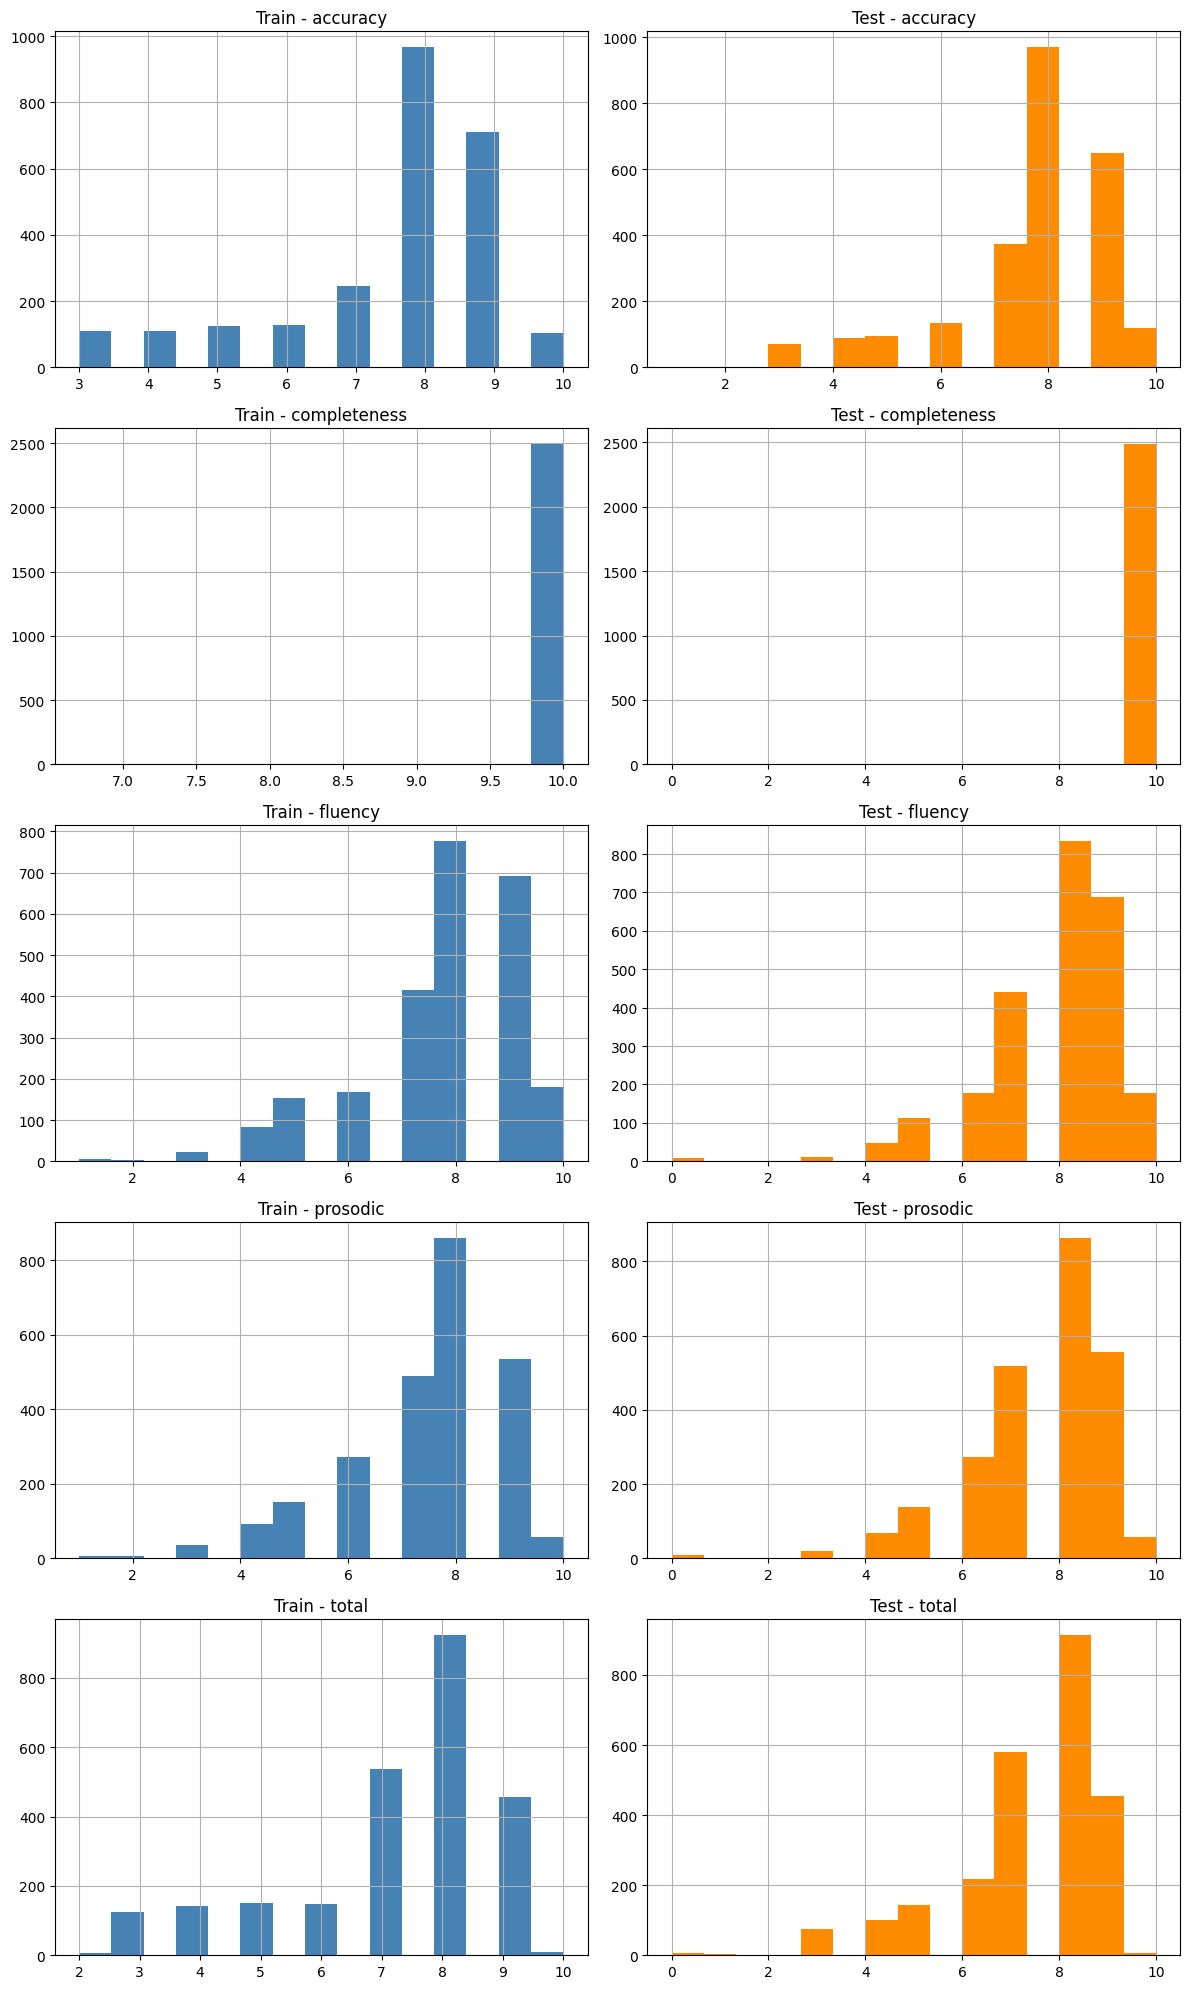

In [9]:
import matplotlib.pyplot as plt

numeric_cols = ["accuracy", "completeness", "fluency", "prosodic", "total"]

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    train_df[col].hist(ax=axes[i][0], bins=15, color="steelblue")
    axes[i][0].set_title(f"Train - {col}")

    test_df[col].hist(ax=axes[i][1], bins=15, color="darkorange")
    axes[i][1].set_title(f"Test - {col}")

plt.tight_layout()
plt.show()

All four detail scores (accuracy, fluency, prosodic — and completeness with much less spread) are left-skewed, meaning most speakers score fairly well (7-9 out of 10) with a smaller tail of low scores.

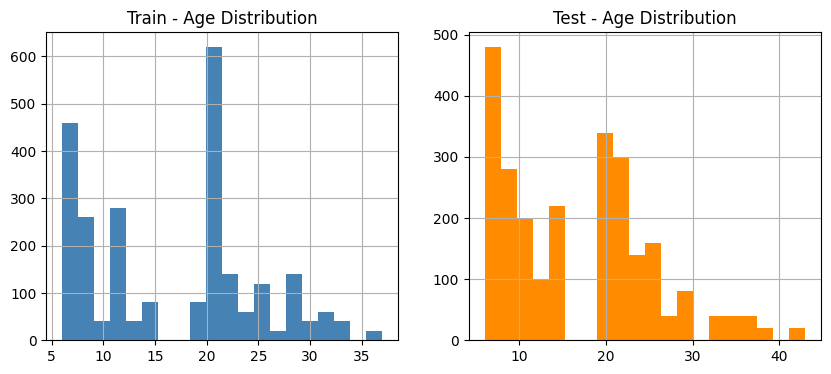

Train age range: 6 - 37
Test age range: 6 - 43


In [10]:
# Age Column
fig, axes = plt.subplots(1, 2, figsize=(10,4))
train_df["age"].hist(ax=axes[0], bins=20, color="steelblue")
axes[0].set_title("Train - Age Distribution")

test_df["age"].hist(ax=axes[1], bins=20, color="darkorange")
axes[1].set_title("Test - Age Distribution")
plt.show()

print("Train age range:", train_df["age"].min(), "-", train_df["age"].max())
print("Test age range:", test_df["age"].min(), "-", test_df["age"].max())

The distribution is clearly bimodal, with one cluster around ages 6-15 (children) and another around ages 20-30 (adults).not a continuous age range. This is important context: pronunciation patterns and error types may differ significantly between these two groups, so results should ideally be interpreted per-group, not just in aggregate. Train and test show consistent age ranges (6-37 vs 6-43), though test includes a few older outliers.

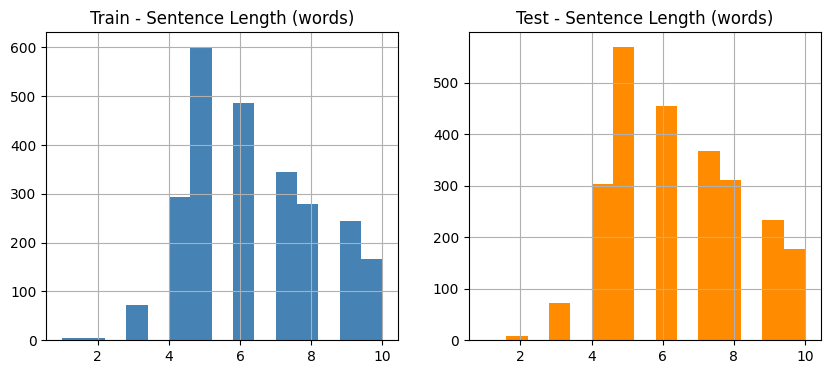

In [11]:
train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["text_length"] = test_df["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
train_df["text_length"].hist(ax=axes[0], bins=15, color="steelblue")
axes[0].set_title("Train - Sentence Length (words)")

test_df["text_length"].hist(ax=axes[1], bins=15, color="darkorange")
axes[1].set_title("Test - Sentence Length (words)")
plt.show()

Sentence lengths range mostly between 4-10 words, peaking around 5-6 words, with a very similar shape in both train and test splits. This consistency confirms the splits are comparable in terms of prompt complexity

In [12]:
# Word column
import pandas as pd

def flatten_words(df, split_name):
    rows = []

    for idx, row in df.iterrows():
        sentence_words = row["words"]

        for w in sentence_words:
            rows.append({
                "utt_index": idx,
                "speaker": row["speaker"],
                "gender": row["gender"],
                "age": row["age"],
                "sentence_text": row["text"],
                "word_text": w["text"],
                "word_accuracy": w["accuracy"],
                "word_total": w["total"],
                "stress": w["stress"],
                "mispronunciations": w["mispronunciations"],
            })

    result_df = pd.DataFrame(rows)
    result_df["split"] = split_name
    return result_df

train_words_df = flatten_words(train_df, "train")
test_words_df = flatten_words(test_df, "test")

print("Train words shape:", train_words_df.shape)
print("Test words shape:", test_words_df.shape)
train_words_df.head()

Train words shape: (15849, 11)
Test words shape: (15967, 11)


,utt_index,speaker,gender,age,sentence_text,word_text,word_accuracy,word_total,stress,mispronunciations,split
0,0,0001,m,6,WE CALL IT BEAR,WE,10,10,10,[],train
1,0,0001,m,6,WE CALL IT BEAR,CALL,10,10,10,[],train
2,0,0001,m,6,WE CALL IT BEAR,IT,10,10,10,[],train
3,0,0001,m,6,WE CALL IT BEAR,BEAR,6,6,10,[],train
4,1,0001,m,6,ZERO THREE FIVE ONE,ZERO,8,7,10,[],train


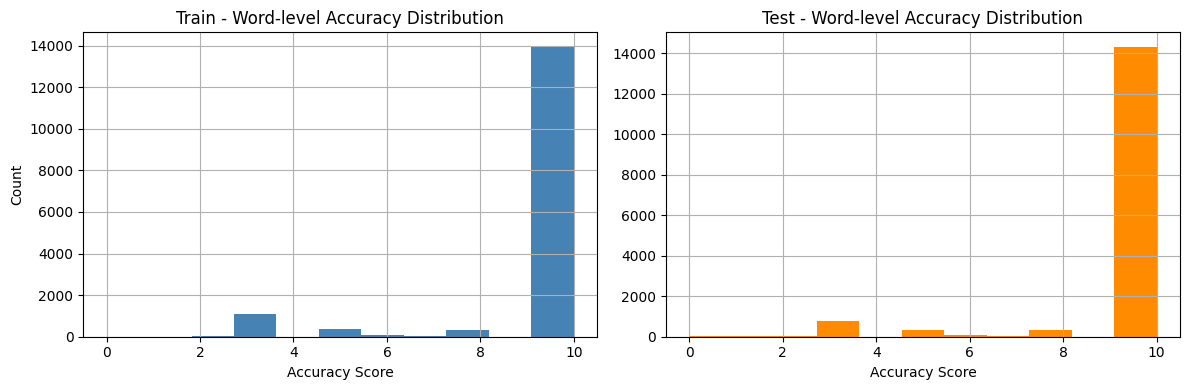

Train word_accuracy stats:
count    15849.000000
mean         9.319074
std          1.959996
min          0.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: word_accuracy, dtype: float64

Test word_accuracy stats:
count    15967.000000
mean         9.436525
std          1.790503
min          0.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: word_accuracy, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

train_words_df["word_accuracy"].hist(ax=axes[0], bins=11, color="steelblue")
axes[0].set_title("Train - Word-level Accuracy Distribution")
axes[0].set_xlabel("Accuracy Score")
axes[0].set_ylabel("Count")

test_words_df["word_accuracy"].hist(ax=axes[1], bins=11, color="darkorange")
axes[1].set_title("Test - Word-level Accuracy Distribution")
axes[1].set_xlabel("Accuracy Score")

plt.tight_layout()
plt.show()

print("Train word_accuracy stats:")
print(train_words_df["word_accuracy"].describe())
print("\nTest word_accuracy stats:")
print(test_words_df["word_accuracy"].describe())

In [14]:
print("Train word_accuracy value counts:")
print(train_words_df["word_accuracy"].value_counts().sort_index())

print("\nTest word_accuracy value counts:")
print(test_words_df["word_accuracy"].value_counts().sort_index())

print(f"\n% of words with accuracy < 10 (train): {(train_words_df['word_accuracy'] < 10).mean()*100:.1f}%")
print(f"% of words with accuracy < 10 (test): {(test_words_df['word_accuracy'] < 10).mean()*100:.1f}%")
print(f"% of words with accuracy <= 5 (train): {(train_words_df['word_accuracy'] <= 5).mean()*100:.1f}%")

Train word_accuracy value counts:
word_accuracy
0         3
1         6
2        40
3      1094
5       349
6        62
7        30
8       322
9         3
10    13940
Name: count, dtype: int64

Test word_accuracy value counts:
word_accuracy
0        27
1        18
2        26
3       787
4         6
5       356
6        77
7        26
8       321
9         4
10    14319
Name: count, dtype: int64

% of words with accuracy < 10 (train): 12.0%
% of words with accuracy < 10 (test): 10.3%
% of words with accuracy <= 5 (train): 9.4%


**Note on word-level accuracy distribution — Final summary:**
- ~88-90% of words have perfect accuracy (10)
- ~9-10% of words show clear pronunciation issues (accuracy ≤ 5)
- Only ~2-3% fall in the "borderline" range (6-9)

This near-binary pattern (mostly perfect vs. clearly problematic, with very
few borderline cases) is actually useful for our threshold calibration:
it suggests the confidence-based threshold doesn't need to be finely tuned
to capture subtle gradations — it mainly needs to reliably separate the
small but important minority of clearly mispronounced words (~10%) from
the majority of correct ones. We will treat this ~10% as our target
"positive class" when evaluating how well WhisperX confidence scores
identify real pronunciation problems.

## EDA Summary — speechocean762

### Dataset Overview
- 2,500 utterances / 125 speakers per split (train & test), officially balanced with **zero speaker overlap** between splits — confirming no data leakage risk for evaluation.
- No missing values in any column across both splits.

### Speaker Demographics
- **Age:** Bimodal distribution — one cluster ~6-15 (children), another ~20-30 (adults), consistent with dataset documentation (child + adult non-native learners as two distinct groups). Consistent range across train/test.
- **Gender:** Train: 1340F/1160M — Test: 1340M/1160F (reversed but balanced overall, ~54%/46%). Not severe enough to require rebalancing; flagged for a quick post-evaluation performance check.

### Sentence-Level Scores
- `completeness` has very high mean (~9.99) and low variance — nearly all speakers say the full sentence. Limited discriminative value.
- `accuracy`, `fluency`, `prosodic` show more spread (std ~1.4-1.7) — most useful signals.
- Test set contains more extreme low scores (min=0) than train (min=2) — test includes harder cases.
- Sentence length: mostly 4-10 words, peak at 5-6, consistent shape across train/test.

### Word-Level Accuracy (Key Finding)
- After flattening: 15,849 words (train) / 15,967 words (test), ~6.3-6.4 words/sentence.
- **Severe class imbalance:** ~88-90% of words have perfect accuracy (10), ~9-10% show clear issues (≤5), only ~2-3% fall in a "borderline" range (6-9).
- Distribution is near-binary (mostly perfect vs. clearly problematic) rather than gradual — simplifies threshold design but requires imbalance-aware evaluation.

### Implications for Threshold Calibration
1. The ~10% of words with accuracy ≤5 will be treated as the target "positive class" (real pronunciation problems) when evaluating WhisperX confidence scores.
2. Standard accuracy is a misleading evaluation metric here — **Precision and Recall** will be used instead to properly assess how well confidence scores separate problematic words from correct ones.
3. Given the bimodal age distribution, WhisperX performance should ideally be checked separately for children vs. adult speakers as a follow-up.

### Next Steps
- Quick audio format check (sample rate, duration) before running WhisperX.
- Run WhisperX on a sample of speechocean762 audio, extract per-word confidence.
- Compare confidence scores against `word_accuracy` (esp. the ≤5 subset) to calibrate a threshold using Precision/Recall.